# 1. Bussines description

### kakkle competition 0.924

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/indian-railways-predict-train-delay/ir_test.csv
/kaggle/input/competitions/indian-railways-predict-train-delay/ir_train.csv
/kaggle/input/competitions/indian-railways-predict-train-delay/ir_sample_submission.csv
/kaggle/input/competitions/indian-railways-predict-train-delay/ir_data_dictionary.csv


In [2]:
import matplotlib.pyplot as plt

# 2. Data Load

In [3]:
df_train = pd.read_csv("/kaggle/input/competitions/indian-railways-predict-train-delay/ir_train.csv")
df_test = pd.read_csv("/kaggle/input/competitions/indian-railways-predict-train-delay/ir_test.csv")

print("Train shape", df_train.shape)
print("Test shape", df_test.shape)

df_train

Train shape (1500000, 45)
Test shape (375000, 42)


,journey_id,train_number,train_type,departure_date,year,month,day_of_week,departure_hour,is_weekend,is_night_departure,is_peak_hour,is_festival_season,season,zone,zone_abbr,source_station_category,destination_station_category,distance_km,num_scheduled_stops,scheduled_travel_hours,track_doubled,is_hdn_route,traction_type,is_electrified,psr_count,is_circular_route,is_monsoon_season,is_fog_risk,fog_risk_score,zone_fog_index,zone_congestion_index,season_severity_score,loco_age_years,coach_age_years,has_lhb_coaches,is_rake_shared,maintenance_score,seat_utilisation_pct,is_overloaded,late_incoming_rake,is_special_train,route_historical_ontime_pct,primary_delay_cause,delay_minutes,is_delayed
0,IR01717809,12536,Superfast Express,2023-09-18,2023,9,0,7,0,0,1,0,Monsoon,North Western Railway (NWR),NWR,A,B,620,12,10.33,1,0,Dual,1,3,0,1,0,0.00,0.58,0.75,0.78,16.7,7.8,0,1,5.5,88.8,0,0,0,67.8,Flooding / Waterlogging,110,1
1,IR00931776,12806,Superfast Express,2020-04-09,2020,4,3,8,0,0,1,0,Summer,East Central Railway (ECR),ECR,A1,E,1423,18,23.72,1,1,Electric (25kV AC),1,3,0,0,0,0.00,0.55,0.88,0.28,8.1,7.9,1,1,6.6,83.6,0,0,0,57.0,On Time,3,0
2,IR00096904,22416,Vande Bharat Express,2024-12-13,2024,12,4,18,0,0,1,0,Winter/Fog,North Eastern Railway (NER),NER,E,A1,449,13,4.73,1,1,Electric (25kV AC),1,6,0,0,0,0.00,0.78,0.82,0.65,10.2,34.4,1,0,4.1,81.6,0,0,0,81.8,On Time,5,0
3,IR00047736,12250,Garib Rath Express,2018-11-29,2018,11,3,18,0,0,1,0,Autumn,Central Railway (CR),CR,C,D,1443,8,22.20,0,0,Electric (25kV AC),1,0,0,0,0,0.00,0.05,0.85,0.30,37.5,2.5,1,0,5.5,82.1,0,1,0,52.3,Track Congestion,135,1
4,IR00726037,74588,DEMU/MEMU,2020-06-18,2020,6,3,5,0,0,0,0,Monsoon,Northeast Frontier Railway (NFR),NFR,C,D,219,14,5.21,1,0,Electric (25kV AC),1,2,0,1,0,0.00,0.22,0.58,0.82,3.4,37.6,0,1,8.0,58.3,0,1,0,64.3,Track Congestion,154,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1499995,IR01569648,12784,Superfast Express,2020-04-02,2020,4,3,1,0,1,0,1,Summer,South Central Railway (SCR),SCR,E,B,879,7,14.65,1,0,Electric (25kV AC),1,2,0,0,0,0.00,0.04,0.72,0.28,7.6,4.3,1,0,6.7,66.1,0,0,0,71.7,On Time,1,0
1499996,IR00761386,74780,DEMU/MEMU,2018-01-30,2018,1,1,18,0,0,1,0,Winter/Fog,East Central Railway (ECR),ECR,C,D,233,13,5.55,1,0,Electric (25kV AC),1,2,1,0,0,0.00,0.55,0.88,0.78,27.4,16.7,1,1,6.0,83.9,0,0,1,42.5,Level Crossing Delay,139,1
1499997,IR01591784,74201,DEMU/MEMU,2020-05-28,2020,5,3,4,0,1,0,1,Pre-Monsoon,Central Railway (CR),CR,A,D,163,15,3.88,0,0,Electric (25kV AC),1,6,0,0,0,0.00,0.05,0.85,0.35,19.1,9.1,1,0,4.2,94.5,0,0,0,51.4,Level Crossing Delay,116,1
1499998,IR01421505,11433,Mail/Express,2021-04-08,2021,4,3,6,0,0,1,0,Summer,South Western Railway (SWR),SWR,B,C,512,8,9.85,1,1,Electric (25kV AC),1,2,0,0,0,0.00,0.02,0.60,0.28,25.1,37.3,1,0,5.5,69.4,0,1,0,82.1,On Time,14,0


In [4]:
train_cols = set(df_train.columns)
test_cols  = set(df_test.columns)

missing_in_test = train_cols - test_cols
missing_in_test

{'delay_minutes', 'is_delayed', 'primary_delay_cause'}

In [5]:
cols_to_drop = [
    "delay_minutes",
    "delay_prev",
    "primary_delay_cause"
]

df_train.drop(columns=cols_to_drop, errors="ignore", inplace = True)

# 3. Data Exploration

In [6]:
df_train.columns.tolist()

['journey_id',
 'train_number',
 'train_type',
 'departure_date',
 'year',
 'month',
 'day_of_week',
 'departure_hour',
 'is_weekend',
 'is_night_departure',
 'is_peak_hour',
 'is_festival_season',
 'season',
 'zone',
 'zone_abbr',
 'source_station_category',
 'destination_station_category',
 'distance_km',
 'num_scheduled_stops',
 'scheduled_travel_hours',
 'track_doubled',
 'is_hdn_route',
 'traction_type',
 'is_electrified',
 'psr_count',
 'is_circular_route',
 'is_monsoon_season',
 'is_fog_risk',
 'fog_risk_score',
 'zone_fog_index',
 'zone_congestion_index',
 'season_severity_score',
 'loco_age_years',
 'coach_age_years',
 'has_lhb_coaches',
 'is_rake_shared',
 'maintenance_score',
 'seat_utilisation_pct',
 'is_overloaded',
 'late_incoming_rake',
 'is_special_train',
 'route_historical_ontime_pct',
 'is_delayed']

In [7]:
# Eliminare duplicate pe linie 
# Delete the duplicated rows
duplicates = df_train[df_train.duplicated()]
print(f"Duplicates found: {len(duplicates)}")

df = df_train.drop_duplicates()
df

Duplicates found: 0


,journey_id,train_number,train_type,departure_date,year,month,day_of_week,departure_hour,is_weekend,is_night_departure,is_peak_hour,is_festival_season,season,zone,zone_abbr,source_station_category,destination_station_category,distance_km,num_scheduled_stops,scheduled_travel_hours,track_doubled,is_hdn_route,traction_type,is_electrified,psr_count,is_circular_route,is_monsoon_season,is_fog_risk,fog_risk_score,zone_fog_index,zone_congestion_index,season_severity_score,loco_age_years,coach_age_years,has_lhb_coaches,is_rake_shared,maintenance_score,seat_utilisation_pct,is_overloaded,late_incoming_rake,is_special_train,route_historical_ontime_pct,is_delayed
0,IR01717809,12536,Superfast Express,2023-09-18,2023,9,0,7,0,0,1,0,Monsoon,North Western Railway (NWR),NWR,A,B,620,12,10.33,1,0,Dual,1,3,0,1,0,0.00,0.58,0.75,0.78,16.7,7.8,0,1,5.5,88.8,0,0,0,67.8,1
1,IR00931776,12806,Superfast Express,2020-04-09,2020,4,3,8,0,0,1,0,Summer,East Central Railway (ECR),ECR,A1,E,1423,18,23.72,1,1,Electric (25kV AC),1,3,0,0,0,0.00,0.55,0.88,0.28,8.1,7.9,1,1,6.6,83.6,0,0,0,57.0,0
2,IR00096904,22416,Vande Bharat Express,2024-12-13,2024,12,4,18,0,0,1,0,Winter/Fog,North Eastern Railway (NER),NER,E,A1,449,13,4.73,1,1,Electric (25kV AC),1,6,0,0,0,0.00,0.78,0.82,0.65,10.2,34.4,1,0,4.1,81.6,0,0,0,81.8,0
3,IR00047736,12250,Garib Rath Express,2018-11-29,2018,11,3,18,0,0,1,0,Autumn,Central Railway (CR),CR,C,D,1443,8,22.20,0,0,Electric (25kV AC),1,0,0,0,0,0.00,0.05,0.85,0.30,37.5,2.5,1,0,5.5,82.1,0,1,0,52.3,1
4,IR00726037,74588,DEMU/MEMU,2020-06-18,2020,6,3,5,0,0,0,0,Monsoon,Northeast Frontier Railway (NFR),NFR,C,D,219,14,5.21,1,0,Electric (25kV AC),1,2,0,1,0,0.00,0.22,0.58,0.82,3.4,37.6,0,1,8.0,58.3,0,1,0,64.3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1499995,IR01569648,12784,Superfast Express,2020-04-02,2020,4,3,1,0,1,0,1,Summer,South Central Railway (SCR),SCR,E,B,879,7,14.65,1,0,Electric (25kV AC),1,2,0,0,0,0.00,0.04,0.72,0.28,7.6,4.3,1,0,6.7,66.1,0,0,0,71.7,0
1499996,IR00761386,74780,DEMU/MEMU,2018-01-30,2018,1,1,18,0,0,1,0,Winter/Fog,East Central Railway (ECR),ECR,C,D,233,13,5.55,1,0,Electric (25kV AC),1,2,1,0,0,0.00,0.55,0.88,0.78,27.4,16.7,1,1,6.0,83.9,0,0,1,42.5,1
1499997,IR01591784,74201,DEMU/MEMU,2020-05-28,2020,5,3,4,0,1,0,1,Pre-Monsoon,Central Railway (CR),CR,A,D,163,15,3.88,0,0,Electric (25kV AC),1,6,0,0,0,0.00,0.05,0.85,0.35,19.1,9.1,1,0,4.2,94.5,0,0,0,51.4,1
1499998,IR01421505,11433,Mail/Express,2021-04-08,2021,4,3,6,0,0,1,0,Summer,South Western Railway (SWR),SWR,B,C,512,8,9.85,1,1,Electric (25kV AC),1,2,0,0,0,0.00,0.02,0.60,0.28,25.1,37.3,1,0,5.5,69.4,0,1,0,82.1,0


In [8]:

# Chech for null & missing 
print("✔ Success") 
print("✘ Error") 
print("? Further investigation")

summary = pd.DataFrame({
    'Unique Values': df_train.nunique(),
    'Non-Null Count': df_train.notna().sum(),
    'Non-Null (%)': (df_train.notna().mean() * 100).round(2),
    'Missing Count': df_train.isna().sum(),
    'Missing (%)': (df_train.isna().mean() * 100).round(2),
    'Data Type': df_train.dtypes
})

summary['Result'] = np.where(
    (summary['Missing (%)'] == 0) & (summary['Data Type'] == 'int64'),
    "✔",
    "✘"
)

summary

✔ Success
✘ Error
? Further investigation


,Unique Values,Non-Null Count,Non-Null (%),Missing Count,Missing (%),Data Type,Result
journey_id,1500000,1500000,100.0,0,0.0,object,✘
train_number,6293,1500000,100.0,0,0.0,int64,✔
train_type,15,1500000,100.0,0,0.0,object,✘
departure_date,2556,1500000,100.0,0,0.0,object,✘
year,7,1500000,100.0,0,0.0,int64,✔
month,12,1500000,100.0,0,0.0,int64,✔
day_of_week,7,1500000,100.0,0,0.0,int64,✔
departure_hour,24,1500000,100.0,0,0.0,int64,✔
is_weekend,2,1500000,100.0,0,0.0,int64,✔
is_night_departure,2,1500000,100.0,0,0.0,int64,✔


# 4. Column selection & Column transformation

In [9]:
# ananlyze the seazon severity by seazon
df.groupby("season")["season_severity_score"].describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
Autumn,122704.0,0.300000,1.375017e-13,0.30,0.30,0.30,0.30,0.30
Monsoon,500798.0,0.845838,4.765695e-02,0.78,0.82,0.88,0.90,0.90
Post-Monsoon,127778.0,0.420000,1.192606e-12,0.42,0.42,0.42,0.42,0.42
Pre-Monsoon,127469.0,0.350000,8.264533e-13,0.35,0.35,0.35,0.35,0.35
Summer,250478.0,0.264753,1.499800e-02,0.25,0.25,0.25,0.28,0.28
Winter/Fog,370773.0,0.716764,5.390810e-02,0.65,0.65,0.72,0.78,0.78


In [10]:
# seazon and season_severity_score are the same thing
df_train.drop(columns=["season"], inplace=True, errors="ignore")

In [11]:
train_special_ratio = (
    df.groupby('train_number')['is_special_train']
      .mean()
      .sort_values(ascending=False)
)

train_special_ratio.head(20)

# Interpretare:

# ≈ 1.0 → tren aproape mereu special
# ≈ 0.0 → tren niciodată special
# între 0 și 1 → tren devine special doar în anumite perioade

train_number
82324    0.400000
82140    0.400000
82171    0.368421
82895    0.368421
82373    0.333333
82863    0.333333
82118    0.312500
82588    0.312500
82498    0.312500
82573    0.312500
82834    0.307692
82564    0.300000
82481    0.300000
82896    0.294118
82941    0.294118
82534    0.285714
82660    0.285714
82255    0.272727
82363    0.272727
82256    0.272727
Name: is_special_train, dtype: float64

In [12]:
train_special_ratio.describe()

count    6293.000000
mean        0.099263
std         0.035290
min         0.000000
25%         0.082927
50%         0.098876
75%         0.114238
max         0.400000
Name: is_special_train, dtype: float64

In [13]:
pd.crosstab(df['train_number'], df['is_special_train'])

is_special_train,0,1
train_number,,
11100,395,40
11101,385,49
11102,425,47
11103,456,48
11104,412,39
...,...,...
82994,12,1
82995,15,3
82996,19,1


# 5. Data Visualization

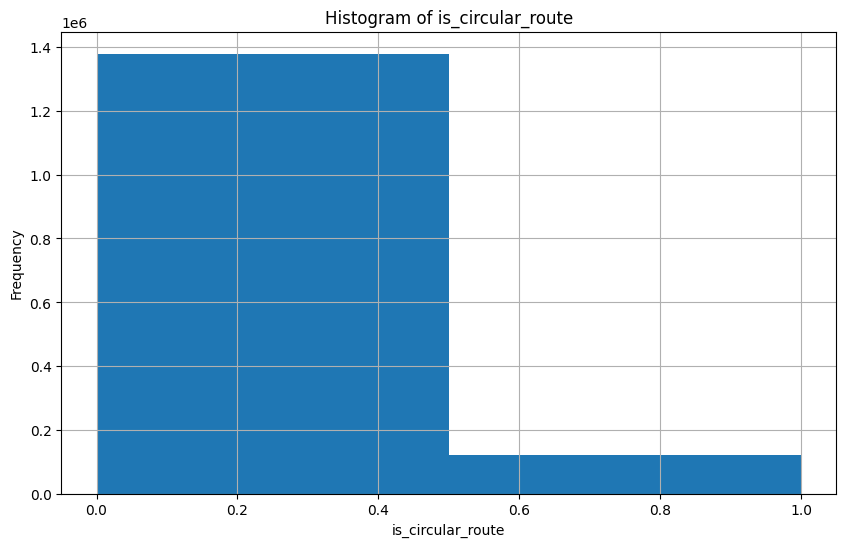

In [14]:
plt.figure(figsize=(10,6))
df["is_circular_route"].hist(bins=2)
plt.xlabel("is_circular_route")
plt.ylabel("Frequency")
plt.title("Histogram of is_circular_route")
plt.show()

### Even though circular routes are much fewer in number, the proportion of delayed vs. on-time trains within them is roughly the same. is_circular_route can be removed from dataset

# 6. Data Preprocessing

In [15]:
def feature_engineering(df):
    # Datetime + seasonality sin/cos
    df['departure_datetime'] = (
        pd.to_datetime(df['departure_date']) +
        pd.to_timedelta(df['departure_hour'], unit='h')
    )
    
    df['hour'] = df['departure_datetime'].dt.hour
    df['dow']  = df['departure_datetime'].dt.weekday
    df['doy']  = df['departure_datetime'].dt.dayofyear
    
    df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
    df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)
    df['dow_sin']  = np.sin(2*np.pi*df['dow']/7)
    df['dow_cos']  = np.cos(2*np.pi*df['dow']/7)
    df['doy_sin']  = np.sin(2*np.pi*df['doy']/365)
    df['doy_cos']  = np.cos(2*np.pi*df['doy']/365)

    # Lag (train memory)
    #df = df.sort_values(['train_number','departure_datetime'])
    
    #df = df.merge(train_stats, on='train_number', how='left')
    #df = df.drop(columns=['train_number'])
    
    # Feature crosses essentials
    df['route_complexity'] = df['distance_km'] / df['num_scheduled_stops']
    df['planned_speed'] = df['distance_km'] / df['scheduled_travel_hours']
    
    df['infra_pressure'] = (
        df['is_hdn_route'] *
        df['zone_congestion_index'] *
        df['is_peak_hour']
    )
    
    df['fog_exposure'] = (
        df['zone_fog_index'] *
        df['fog_risk_score'] *
        df['is_night_departure']
    )
    
    df = df.sort_values('departure_datetime')
    
    # remove useless columns
    df = df.drop(columns=[
        'departure_date','year','month','day_of_week','departure_hour',
        'hour','dow','doy','departure_datetime',
        'journey_id',
        'zone_abbr',
        'train_number'
        
    ])

    return df

In [16]:
train = feature_engineering(df_train)

test  = feature_engineering(df_test)

In [17]:
# data separartion
X = train.drop(columns=['is_delayed'])
y = train['is_delayed']
#display(X)

X_test = test[X.columns]

In [20]:
from catboost import CatBoostClassifier



model = CatBoostClassifier(
    iterations=600,
    depth=8,
    learning_rate=0.05,
    verbose=100
)

#model.fit(X_train, y_train, cat_features=cat_cols)

In [21]:
%%time
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model.fit(
        X_train, y_train,
        cat_features=cat_cols,
        eval_set=(X_val, y_val),
        verbose=False
    )

In [19]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier
import time

cat_cols = X.select_dtypes('object').columns.tolist()

tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    print(f"\n===== FOLD {fold+1} =====")
    t0 = time.perf_counter()

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=2000,
        depth=8,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="AUC",
        early_stopping_rounds=100,
        verbose=200
    )

    model.fit(
        X_train, y_train,
        cat_features=cat_cols,
        eval_set=(X_val, y_val)
    )

    preds = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds)

    dt = time.perf_counter() - t0
    print(f"FOLD {fold+1} AUC: {auc:.4f} | time: {dt/60:.2f} min")


===== FOLD 1 =====
0:	test: 0.8919564	best: 0.8919564 (0)	total: 346ms	remaining: 11m 31s
200:	test: 0.9218380	best: 0.9218380 (200)	total: 53.5s	remaining: 7m 58s
400:	test: 0.9220036	best: 0.9220398 (305)	total: 1m 44s	remaining: 6m 57s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9220398324
bestIteration = 305

Shrink model to first 306 iterations.
FOLD 1 AUC: 0.9220 | time: 1.79 min

===== FOLD 2 =====
0:	test: 0.8959892	best: 0.8959892 (0)	total: 541ms	remaining: 18m
200:	test: 0.9240906	best: 0.9240906 (200)	total: 1m 26s	remaining: 12m 55s
400:	test: 0.9243212	best: 0.9243227 (354)	total: 2m 52s	remaining: 11m 28s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.924323861
bestIteration = 413

Shrink model to first 414 iterations.
FOLD 2 AUC: 0.9243 | time: 3.71 min

===== FOLD 3 =====
0:	test: 0.8996024	best: 0.8996024 (0)	total: 716ms	remaining: 23m 52s
200:	test: 0.9270830	best: 0.9270830 (200)	total: 2m 2s	remaining: 18m 12s
400:	t

In [24]:
test_ids = df_test["journey_id"].copy()
X_test = df_test[X.columns]
#test_preds = model.predict(X_test)
test_preds = model.predict_proba(X_test)[:, 1]


In [31]:
submission_df = pd.DataFrame({
    "journey_id": test_ids,
    "pred": test_preds
})

submission_df.sample(10)

,journey_id,pred
318541,IR00314417,0.979210
197816,IR00688883,0.682076
16544,IR00802056,0.999944
338519,IR00045281,0.206880
98840,IR01643788,0.989453
221233,IR00382304,0.968818
82548,IR00863979,0.748360
158113,IR00274186,0.865020
216408,IR00171595,0.822708
24622,IR01021128,0.991348


In [32]:
submission_df.to_csv("/kaggle/working/submission.csv", index=False)

In [33]:
pd.read_csv("/kaggle/working/submission.csv").head()

,journey_id,pred
0,IR01679028,0.237641
1,IR01531216,0.252958
2,IR01076165,0.997020
3,IR00956901,0.512505
4,IR00470951,0.958911
